# 🎨 Visualizing Quantization: Building Intuition

Welcome! This notebook is designed for Computer Science students to build a strong, visual intuition for **Neural Network Quantization** and the **AWQ (Activation-aware Weight Quantization)** algorithm.

We'll use standard Python libraries (`numpy`, `matplotlib`, `seaborn`) to simulate:
1. How continuous weights map to discrete buckets (INT8, INT4, INT2)
2. The "Outlier Problem" in Round-to-Nearest (RTN) quantization
3. How AWQ's scaling trick elegantly solves the outlier problem

Let's dive in!

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set matplotlib style for nice, professional charts
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.2)

---
## Part 1: The Basics — Continuous to Discrete

Imagine model weights are smooth waves (like a sine wave). **Quantization** is the process of forcing these smooth, continuous values (FP16/FP32) into a limited number of discrete "buckets" or "steps" (Integers).

- **8-bit (INT8)** has $2^8 = 256$ buckets.
- **4-bit (INT4)** has $2^4 = 16$ buckets.
- **2-bit (INT2)** has $2^2 = 4$ buckets.

Let's visualize this precision loss.

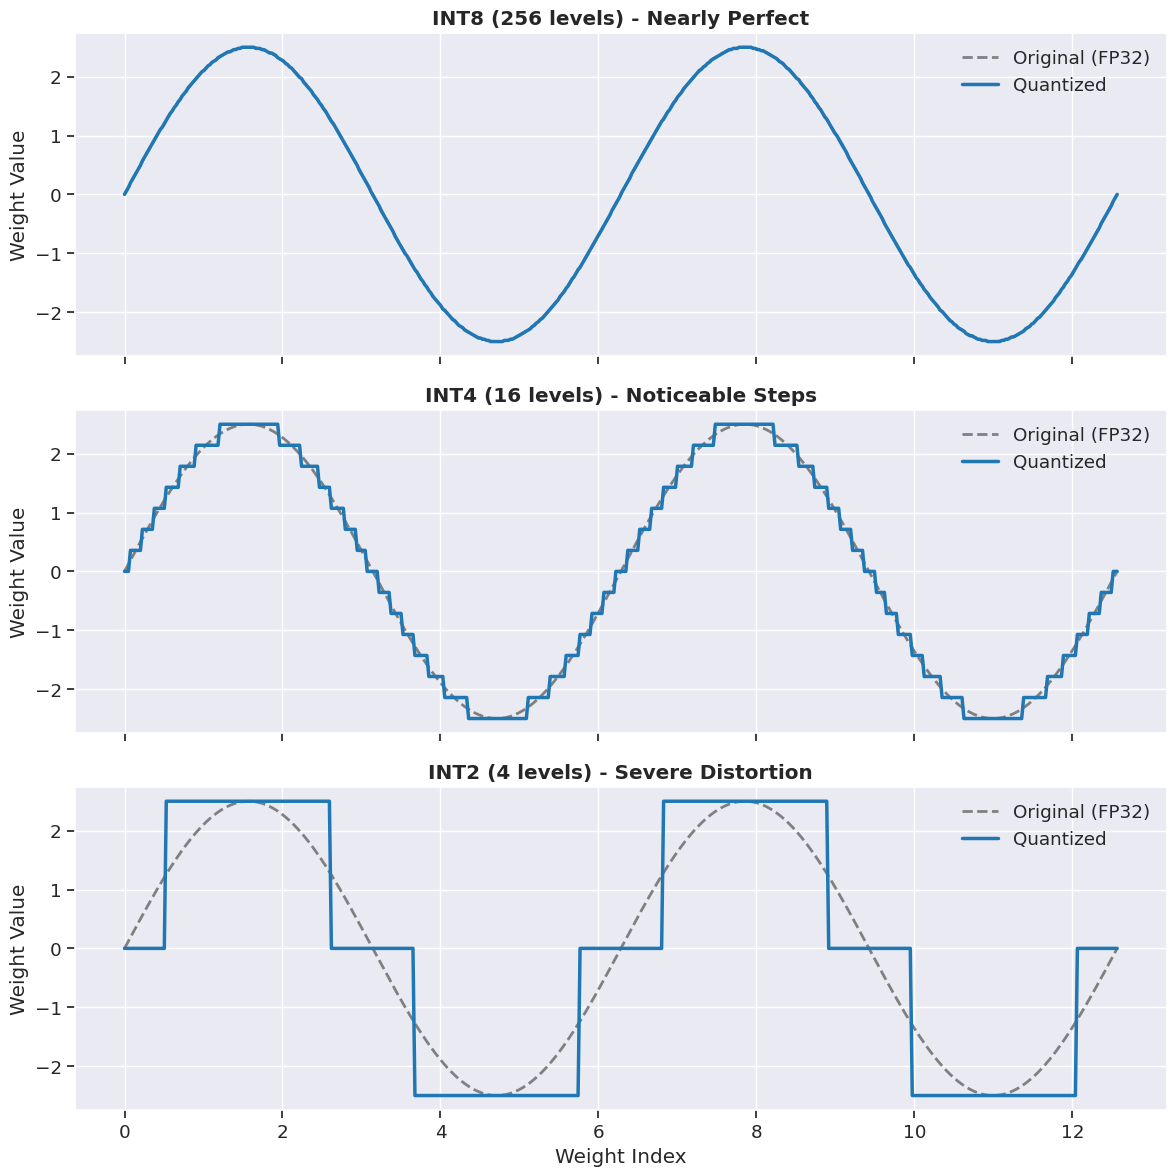

In [2]:
def quantize_and_dequantize(x, bits):
    """Simulates symmetric RTN (Round-to-Nearest) quantization."""
    # 1. Find the maximum absolute value to determine the scale (Delta)
    max_val = np.max(np.abs(x))
    
    # Number of positive buckets (e.g., for 4-bit, max int is 7)
    max_q = 2**(bits - 1) - 1  
    
    # 2. Compute the scale factor (step size)
    scale = max_val / max_q
    
    # 3. Quantize: Divide by scale, round to nearest integer, and clip
    x_q = np.round(x / scale)
    x_q = np.clip(x_q, -max_q, max_q)
    
    # 4. Dequantize: Multiply back by scale (this is what the GPU sees during inference)
    x_dq = x_q * scale
    return x_dq

# Generate a smooth "weight" curve
x = np.linspace(0, 4 * np.pi, 500)
weights_fp32 = np.sin(x) * 2.5 # Values from -2.5 to 2.5

# Quantize to different bit-widths
weights_int8 = quantize_and_dequantize(weights_fp32, bits=8)
weights_int4 = quantize_and_dequantize(weights_fp32, bits=4)
weights_int2 = quantize_and_dequantize(weights_fp32, bits=2)

# Plotting
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
titles = ["INT8 (256 levels) - Nearly Perfect", 
          "INT4 (16 levels) - Noticeable Steps", 
          "INT2 (4 levels) - Severe Distortion"]
quantized_data = [weights_int8, weights_int4, weights_int2]

for i, ax in enumerate(axes):
    ax.plot(x, weights_fp32, label="Original (FP32)", color="gray", linestyle="--", linewidth=2)
    ax.plot(x, quantized_data[i], label=f"Quantized", color="#1f77b4", linewidth=2.5)
    ax.set_title(titles[i], fontweight='bold')
    ax.legend(loc="upper right")
    ax.set_ylabel("Weight Value")

axes[-1].set_xlabel("Weight Index")
plt.tight_layout()
plt.show()

**Insight 1:** At **4-bit (INT4)**, the shape is preserved, but you can clearly see the "staircase" effect. This gap between the gray line and the blue line is the **Quantization Error**.

---
## Part 2: The "Outlier" Problem in RTN

The code above assumes all weights are roughly the same size. But in real Large Language Models (LLMs), a few weights (or activations) can be **massive outliers**.

Let's see what happens to a group of 128 weights (a standard AWQ group size) when we have one massive outlier.

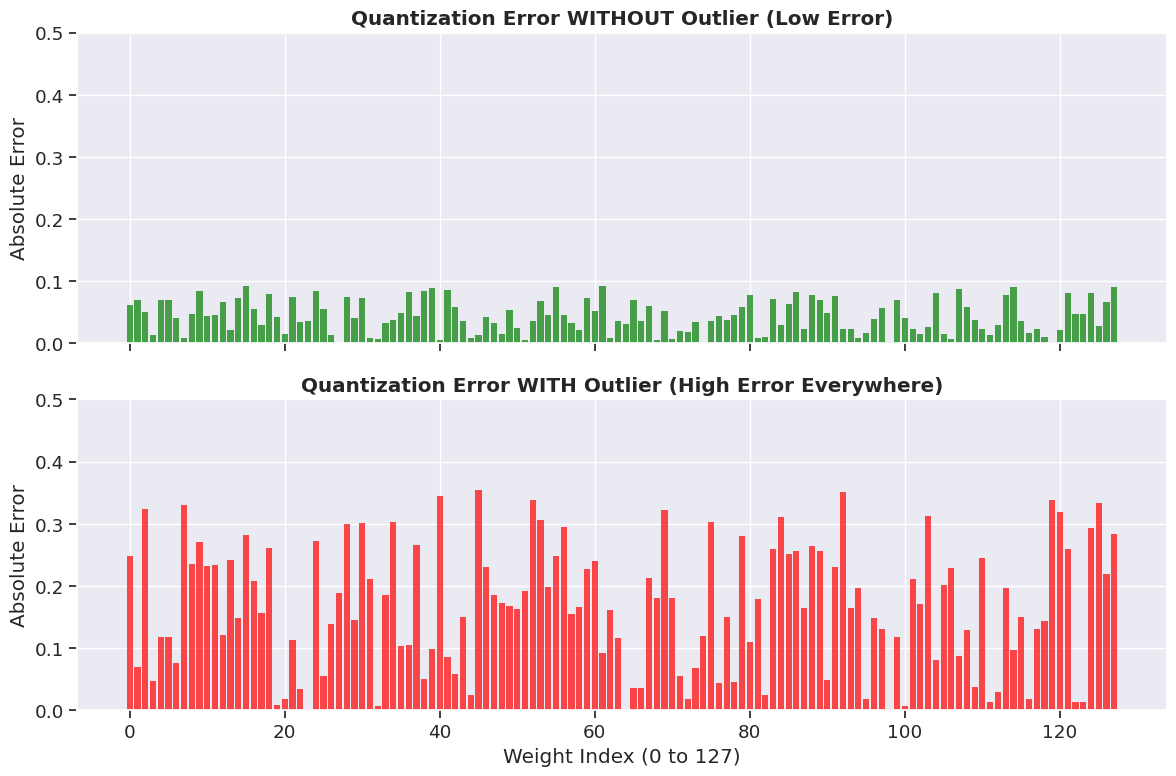

In [3]:
# Generate 128 standard weights (normal distribution around 0)
np.random.seed(42)
normal_weights = np.random.normal(0, 0.5, 128)

# Introduce ONE massive outlier (e.g., magnitude 5.0)
weights_with_outlier = normal_weights.copy()
weights_with_outlier[64] = 5.0  # The "yelling" student

# Quantize both to INT4
q_normal = quantize_and_dequantize(normal_weights, bits=4)
q_outlier = quantize_and_dequantize(weights_with_outlier, bits=4)

# Calculate Quantization Error (Absolute Difference)
err_normal = np.abs(normal_weights - q_normal)
err_outlier = np.abs(weights_with_outlier - q_outlier)

# Plotting
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Plot 1: Standard Weights Error
ax1.bar(range(128), err_normal, color="green", alpha=0.7)
ax1.set_title("Quantization Error WITHOUT Outlier (Low Error)", fontweight='bold')
ax1.set_ylabel("Absolute Error")
ax1.set_ylim(0, 0.5)

# Plot 2: Weights with Outlier Error
ax2.bar(range(128), err_outlier, color="red", alpha=0.7)
ax2.set_title("Quantization Error WITH Outlier (High Error Everywhere)", fontweight='bold')
ax2.set_ylabel("Absolute Error")
ax2.set_xlabel("Weight Index (0 to 127)")
ax2.set_ylim(0, 0.5)

plt.tight_layout()
plt.show()

### 🛑 What just happened?
Look at the red chart! Because of **one** large outlier at index 64, the "step size" (`scale` / $\Delta$) had to become huge to accommodate it. 

Consequently, all the small, normal weights (the whispering students) got squashed into just 1 or 2 buckets around zero. Their precision was destroyed, causing the quantization error (red bars) for the *entire group* to skyrocket.

---
## Part 3: The AWQ Solution (Equivalent Transformation)

AWQ solves this without using mixed precision (where the outlier stays FP16). 

Instead, AWQ uses **Math Magic**: $Y = W \times X = (W / s) \times (X \cdot s)$

If we **divide the outlier column in the weight matrix by $s$** (where $s > 1$), that weight gets physically smaller. The quantization step size for the group shrinks back down, saving the "whispering" weights.

To keep the math correct, we just **multiply the corresponding activation feature by $s$** before the matrix multiplication.

Let's visualize AWQ scaling a $10 \times 10$ weight matrix.

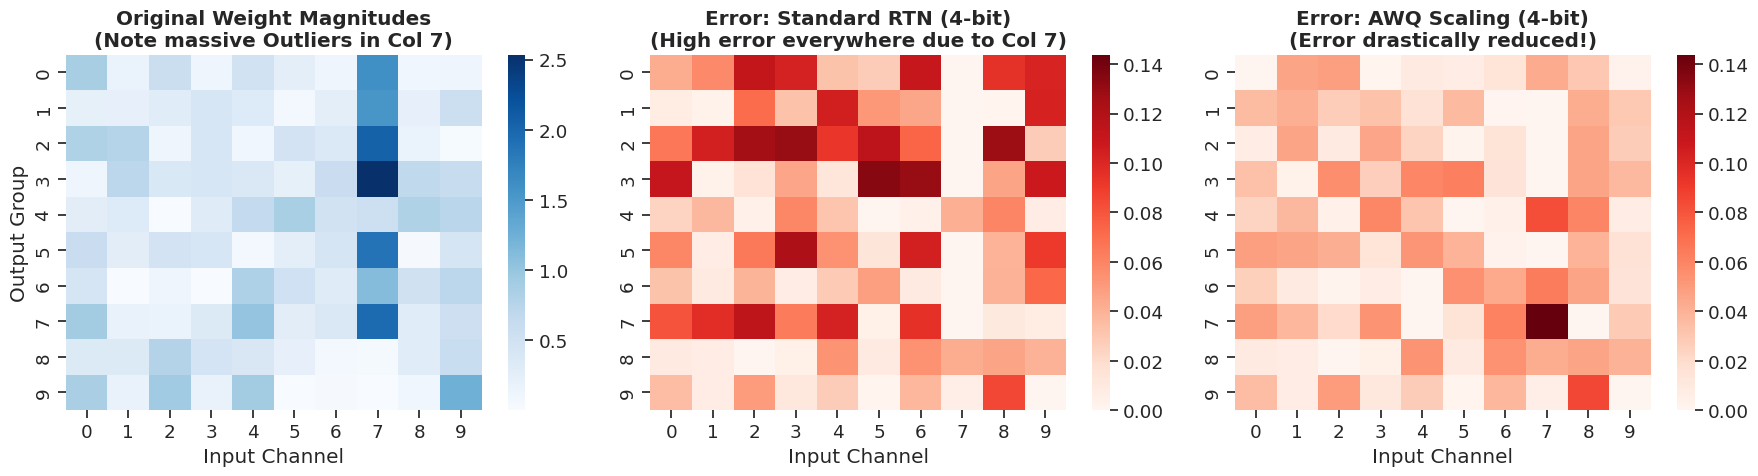

In [4]:
# Create a 10x10 Weight Matrix
np.random.seed(100)
W = np.random.normal(0, 0.5, (10, 10))

# Let's say Input Feature (Channel) #7 has massive activations (Salient Channel!)
# The weights connected to this channel are crucial to protect.
salient_channel = 7

# Let's artificially make the weights in this channel a bit larger too, 
# to simulate an outlier scenario in a quantization group (assuming grouping by row).
W[:, salient_channel] = W[:, salient_channel] * 3.0 

### Standard RTN Quantization (4-bit)
# We quantize per-row (group size = 10 for this toy example)
W_rtn = np.zeros_like(W)
for i in range(10):
    W_rtn[i, :] = quantize_and_dequantize(W[i, :], bits=4)
    
# Calculate RTN Error Matrix
Error_RTN = np.abs(W - W_rtn)

### AWQ SCALING TRICK
# We scale DOWN the salient channel in the weights by a factor of 's=2.5'
s = 2.5
W_scaled = W.copy()
W_scaled[:, salient_channel] = W_scaled[:, salient_channel] / s

# Now quantize the SCALED matrix to 4-bit
W_awq_quantized = np.zeros_like(W)
for i in range(10):
    W_awq_quantized[i, :] = quantize_and_dequantize(W_scaled[i, :], bits=4)

### CALCULATE AWQ ERROR
# To compare errors fairly, we must "undo" the scaling to see the effective error 
# injected into the final matrix multiplication.
# Since the activation X will be multiplied by 's', the effective dequantized weight is W_awq_quantized * s
W_awq_effective = W_awq_quantized.copy()
W_awq_effective[:, salient_channel] = W_awq_effective[:, salient_channel] * s

Error_AWQ = np.abs(W - W_awq_effective)

# Visualize the Heatmaps!
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

vmax = max(np.max(Error_RTN), np.max(Error_AWQ))

# 1. Original Matrix
sns.heatmap(np.abs(W), ax=axes[0], cmap="Blues", cbar=True, annot=False)
axes[0].set_title("Original Weight Magnitudes\n(Note massive Outliers in Col 7)", fontweight='bold')
axes[0].set_xlabel("Input Channel")
axes[0].set_ylabel("Output Group")

# 2. RTN Error
sns.heatmap(Error_RTN, ax=axes[1], cmap="Reds", cbar=True, vmin=0, vmax=vmax)
axes[1].set_title("Error: Standard RTN (4-bit)\n(High error everywhere due to Col 7)", fontweight='bold')
axes[1].set_xlabel("Input Channel")

# 3. AWQ Error
sns.heatmap(Error_AWQ, ax=axes[2], cmap="Reds", cbar=True, vmin=0, vmax=vmax)
axes[2].set_title("Error: AWQ Scaling (4-bit)\n(Error drastically reduced!)", fontweight='bold')
axes[2].set_xlabel("Input Channel")

plt.tight_layout()
plt.show()

### 🏆 The Result

Look at the third heatmap! By simply diving Column 7 by 2.5 *before* rounding, we allowed the other columns (0-6, 8-9) to claim back their precision steps.

In the final matrix multiplication, the hardware mathematically compensates by multiplying the incoming activation features of Column 7 by 2.5.

**End result:** We get a mathematically equivalent output layer, but the quantization error injected into the system is vastly reduced (less red), preserving the LLM's "smartness" while fitting it into 4-bit hardware.